In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import sys
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KernelDensity
from collections import Counter
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
census = pd.read_csv('https://raw.githubusercontent.com/alan-turing-institute/reprosyn/main/src/reprosyn/datasets/2011-census-microdata/2011-census-microdata-small.csv')
data = census.drop(columns = ['Person ID'])
data

,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
0,E12000001,H,2,1,2,6,2,2,1,2,1,2,5,8,2,-9,4
1,E12000001,H,5,1,1,4,1,2,1,1,1,2,1,8,6,4,3
2,E12000001,H,3,1,2,4,1,2,1,1,1,1,1,6,11,3,4
3,E12000001,H,3,1,2,2,1,2,1,2,1,2,1,7,7,3,2
4,E12000001,H,3,1,1,5,4,2,1,1,1,2,1,1,4,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,E12000009,H,2,1,1,1,1,2,1,1,1,1,-9,-9,-9,-9,-9
49996,E12000009,H,2,1,1,1,1,1,1,1,1,2,-9,-9,-9,-9,-9
49997,E12000009,H,2,1,1,1,1,1,1,1,1,9,-9,-9,-9,-9,-9
49998,E12000009,H,2,1,1,4,2,2,1,1,1,2,1,1,5,3,2


In [32]:
with open('../data/census.json', 'r') as f:
    census_description = json.load(f)
    
census_description

[{'name': 'Region',
  'type': 'finite',
  'representation': ['E12000001',
   'E12000002',
   'E12000003',
   'E12000004',
   'E12000005',
   'E12000009',
   'E12000006',
   'E12000008',
   'E12000007',
   'W92000004']},
 {'name': 'Residence Type', 'type': 'finite', 'representation': ['H', 'C']},
 {'name': 'Family Composition',
  'type': 'finite',
  'representation': ['-9', '1', '2', '3', '4', '5', '6']},
 {'name': 'Population Base',
  'type': 'finite',
  'representation': ['1', '2', '3']},
 {'name': 'Sex', 'type': 'finite', 'representation': ['1', '2']},
 {'name': 'Age',
  'type': 'finite',
  'representation': ['1', '2', '3', '4', '5', '6', '7', '8']},
 {'name': 'Marital Status',
  'type': 'finite',
  'representation': ['1', '2', '3', '4', '5']},
 {'name': 'Student', 'type': 'finite', 'representation': ['1', '2']},
 {'name': 'Country of Birth',
  'type': 'finite',
  'representation': ['-9', '1', '2']},
 {'name': 'Health',
  'type': 'finite',
  'representation': ['-9', '1', '2', '3', '4

In [33]:
data

,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
0,E12000001,H,2,1,2,6,2,2,1,2,1,2,5,8,2,-9,4
1,E12000001,H,5,1,1,4,1,2,1,1,1,2,1,8,6,4,3
2,E12000001,H,3,1,2,4,1,2,1,1,1,1,1,6,11,3,4
3,E12000001,H,3,1,2,2,1,2,1,2,1,2,1,7,7,3,2
4,E12000001,H,3,1,1,5,4,2,1,1,1,2,1,1,4,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,E12000009,H,2,1,1,1,1,2,1,1,1,1,-9,-9,-9,-9,-9
49996,E12000009,H,2,1,1,1,1,1,1,1,1,2,-9,-9,-9,-9,-9
49997,E12000009,H,2,1,1,1,1,1,1,1,1,9,-9,-9,-9,-9,-9
49998,E12000009,H,2,1,1,4,2,2,1,1,1,2,1,1,5,3,2


In [34]:
# Split into "train" (members) and "test" (non-members)
train_data, test_data = train_test_split(data, test_size=0.5, random_state=999)

categorical_cols = ['Region', 'Residence Type', 'Family Composition', 'Population Base',
       'Sex', 'Age', 'Marital Status', 'Student', 'Country of Birth', 'Health',
       'Ethnic Group', 'Religion', 'Economic Activity', 'Occupation',
       'Industry', 'Hours worked per week', 'Approximated Social Grade']

numerical_cols = []

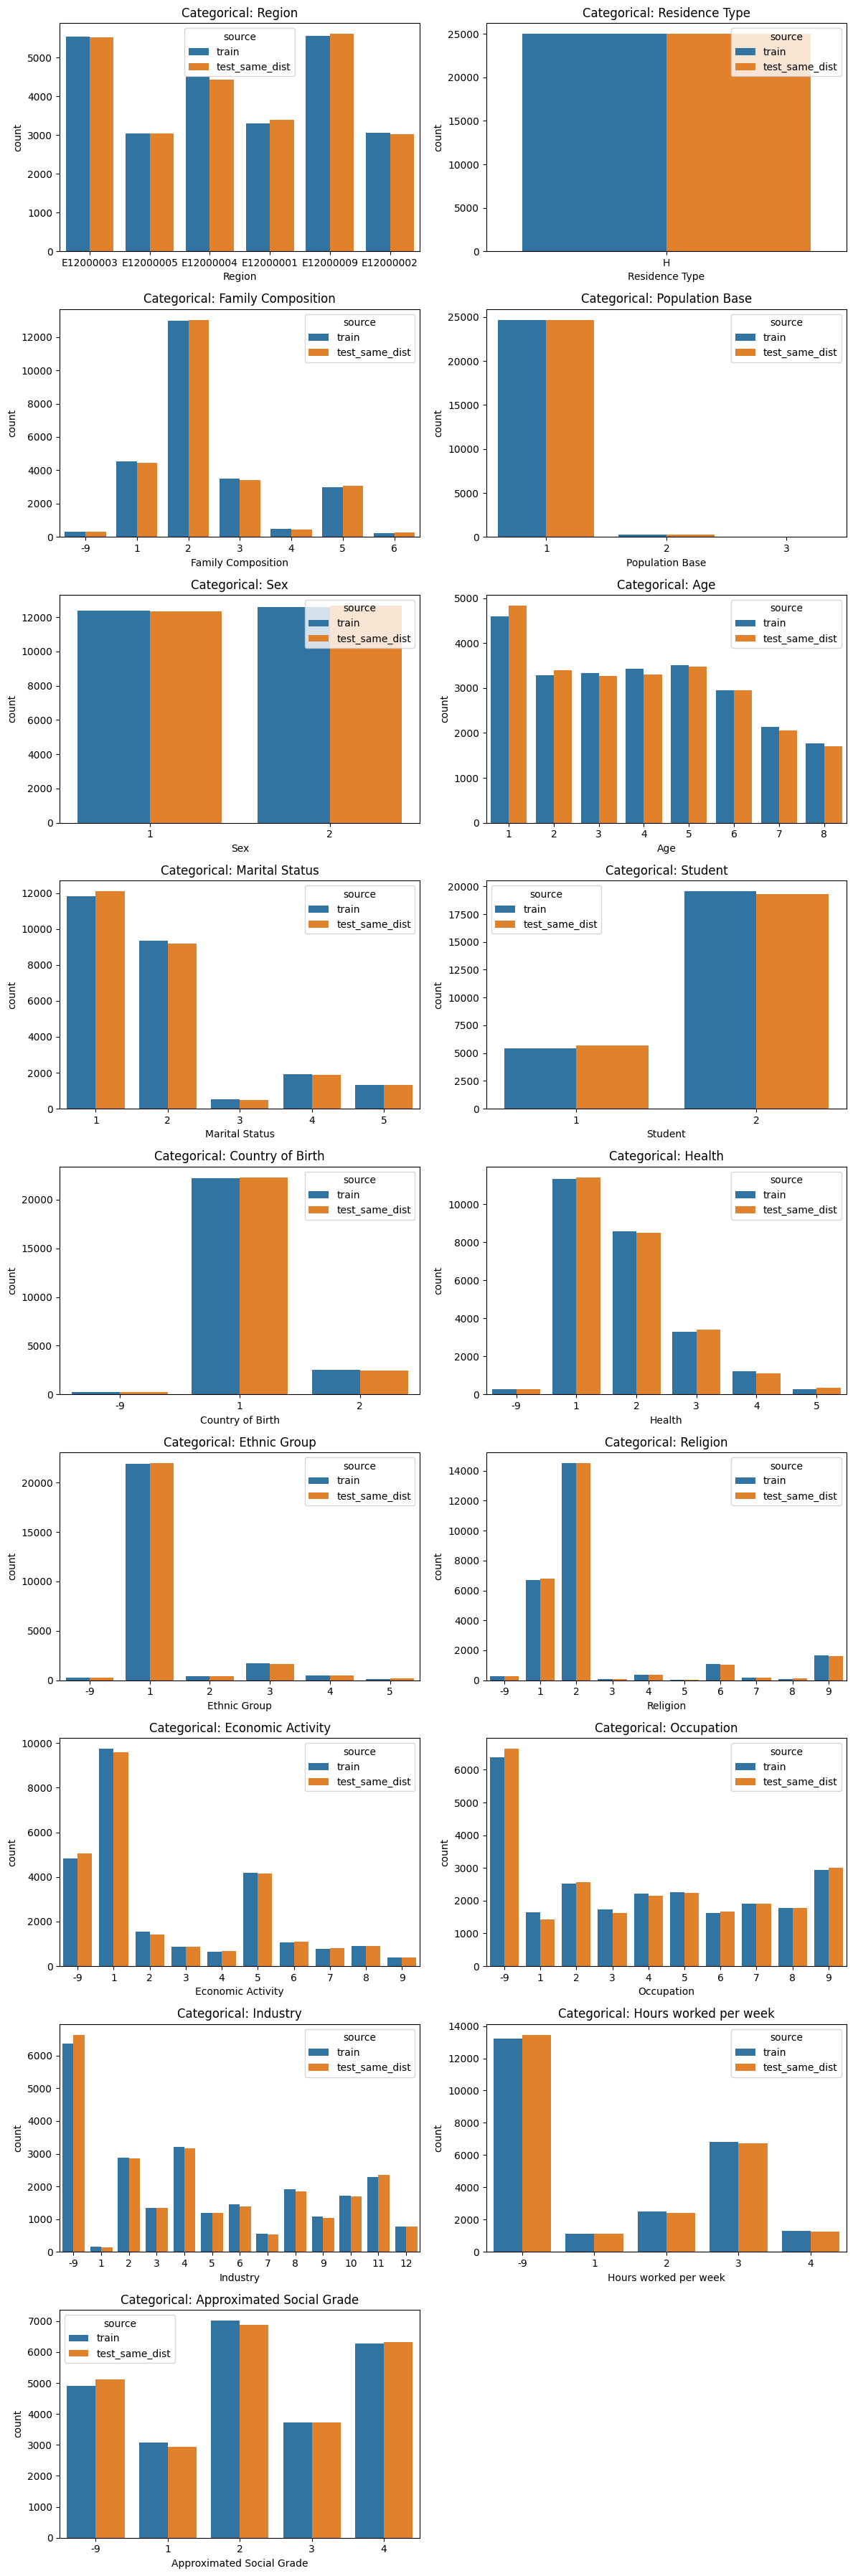

In [35]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(train_data, test_data, categorical_cols, numerical_cols):
    # Label the datasets
    train_labeled = train_data.copy()
    train_labeled["source"] = "train"

    test_labeled = test_data.copy()
    test_labeled["source"] = "test_same_dist"

    # Combine all
    combined = pd.concat([train_labeled, test_labeled])

    # Determine layout
    n_cat = len(categorical_cols)
    n_num = len(numerical_cols)
    total = n_cat + n_num

    ncols = 2
    nrows = (total + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    i = 0
    for col in categorical_cols:
        sns.countplot(data=combined, x=col, hue="source", ax=axes[i])
        axes[i].set_title(f"Categorical: {col}")
        i += 1

    for col in numerical_cols:
        sns.histplot(data=combined, x=col, hue="source", kde=True, bins=20, element="step", ax=axes[i])
        axes[i].set_title(f"Numerical: {col}")
        i += 1

    # Hide unused subplots
    for j in range(i, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt
    
plot_feature_distributions(train_data, test_data, categorical_cols, numerical_cols)

In [ ]:
# binning
def bin_log_likelihoods(log_likelihoods, n_bins=20):
    """Bins log-likelihoods into discrete bins (equal width)."""
    min_ll, max_ll = np.min(log_likelihoods), np.max(log_likelihoods)
    bins = np.linspace(min_ll, max_ll, n_bins + 1)
    binned = np.digitize(log_likelihoods, bins, right=True)
    return binned, bins



In [23]:
# --- Step 2: Estimate Distributions ---

# Categorical probabilities with Laplace smoothing
def estimate_categorical_probs(train, categories, k=1):
    cat_probs = {}
    for col in categories:
        counts = Counter(train[col])
        unique_vals = list(set(train[col].unique()).union(set(test_data[col].unique())))
        total = sum(counts.values())
        probs = {
            val: (counts[val] + k) / (total + k * len(unique_vals))
            for val in unique_vals
        }
        cat_probs[col] = probs
    return cat_probs

# KDE for numerical columns
def estimate_kdes(train, num_cols):
    kde_models = {}
    for col in num_cols:
        kde = KernelDensity(kernel="gaussian", bandwidth=2.0)
        kde.fit(train[[col]])
        kde_models[col] = kde
    return kde_models



# Estimate distributions
cat_probs = estimate_categorical_probs(train_data, categorical_cols)
kde_models = estimate_kdes(train_data, numerical_cols)

In [24]:
# --- Step 3: Compute log-likelihood per row ---

def compute_log_likelihood(row, cat_probs, kde_models):
    log_prob = 0.0

    # Categorical
    for col, probs in cat_probs.items():
        val = row[col]
        p = probs.get(val, 1e-8)  # unseen fallback
        log_prob += math.log(p)

    # Numerical
    for col, kde in kde_models.items():
        val = pd.DataFrame([[row[col]]], columns=[col])
        log_prob += kde.score_samples(val)[0]

    return log_prob

# Compute log-likelihoods
train_ll = train_data.apply(lambda row: compute_log_likelihood(row, cat_probs, kde_models), axis=1)
test_ll = test_data.apply(lambda row: compute_log_likelihood(row, cat_probs, kde_models), axis=1)


In [25]:
train_ll.mean()

-19.95897730827424

In [26]:
train_ll.max()

-13.577435448253151

In [27]:
test_ll.mean()

-19.977510395441357

In [28]:
test_ll.max()

-13.577435448253151

In [36]:
np.mean(train_ll <= test_ll.max())

1.0

In [39]:
# scaled likelihoods (score between 0 and 1)
def get_score(train_ll, point_likelihood):
    return np.mean(train_ll <= point_likelihood)

scaled_scores = [get_score(ll, train_ll) for ll in test_ll]
scaled_scores

[0.6062,
 0.6184,
 0.2027,
 0.2864,
 0.4414,
 0.8408,
 0.829,
 0.7772,
 0.747,
 0.9585,
 0.435,
 0.7915,
 0.4496,
 0.4247,
 0.2879,
 0.7446,
 0.6956,
 0.248,
 0.7516,
 0.2276,
 0.4468,
 0.9888,
 0.8129,
 0.7082,
 0.3713,
 0.4639,
 0.4249,
 0.6521,
 0.58,
 0.0761,
 0.8701,
 0.0218,
 0.7478,
 0.9347,
 0.9392,
 0.7516,
 0.1613,
 0.4832,
 0.3957,
 0.5802,
 0.4337,
 0.2556,
 0.8704,
 0.1006,
 0.8512,
 0.6579,
 0.2764,
 0.7277,
 0.9682,
 0.921,
 0.0166,
 0.7819,
 0.5175,
 0.6164,
 0.1998,
 0.205,
 0.1916,
 0.7088,
 0.6587,
 0.7821,
 0.8741,
 0.4915,
 0.0638,
 0.5757,
 0.1227,
 0.3019,
 0.9331,
 0.8471,
 0.5637,
 0.1704,
 0.8774,
 0.465,
 0.0688,
 0.4753,
 0.634,
 0.5926,
 0.8357,
 0.4973,
 0.3069,
 0.2661,
 0.1074,
 0.5255,
 0.4689,
 0.494,
 0.5639,
 0.0255,
 0.3873,
 0.1069,
 0.1963,
 0.9232,
 0.9972,
 0.3935,
 0.146,
 0.793,
 0.9888,
 0.6537,
 0.0379,
 0.4596,
 0.6135,
 0.815,
 0.8802,
 0.3435,
 0.4753,
 0.367,
 0.57,
 0.7224,
 0.6858,
 0.7935,
 0.9709,
 0.8548,
 0.0605,
 0.0928,
 0.708,
 

In [10]:
# --- Step 4: Membership inference ---

# Choose a threshold: e.g., 20th percentile of training set likelihoods
threshold = np.percentile(train_ll, 20)


# Predict membership
train_pred = train_ll > threshold
test_pred = test_ll > threshold



# --- Step 5: Combine results ---
results = pd.DataFrame({
    "log_likelihood": np.concatenate([train_ll, test_ll]),
    "predicted_member": np.concatenate([train_pred, test_pred]),
    "true_member": np.concatenate([
        np.ones(len(train_ll)),           # members
        np.zeros(len(test_ll)),          # same-dist non-members
       
    ]),
    "source": (["train"] * len(train_ll)) +
              (["test_same_dist"] * len(test_ll)) 
})

from sklearn.metrics import accuracy_score, precision_score, recall_score

# --- Evaluation: Train vs Test (same distribution) ---
subset_same = results[results["source"].isin(["train", "test_same_dist"])]
y_true_same = subset_same["true_member"]
y_pred_same = subset_same["predicted_member"]

print("Train vs Test (same dist):")
print("Accuracy:", accuracy_score(y_true_same, y_pred_same))
print("Precision:", precision_score(y_true_same, y_pred_same))
print("Recall:", recall_score(y_true_same, y_pred_same))
print()




Train vs Test (same dist):
Accuracy: 0.38172
Precision: 0.30064638973793656
Recall: 0.8



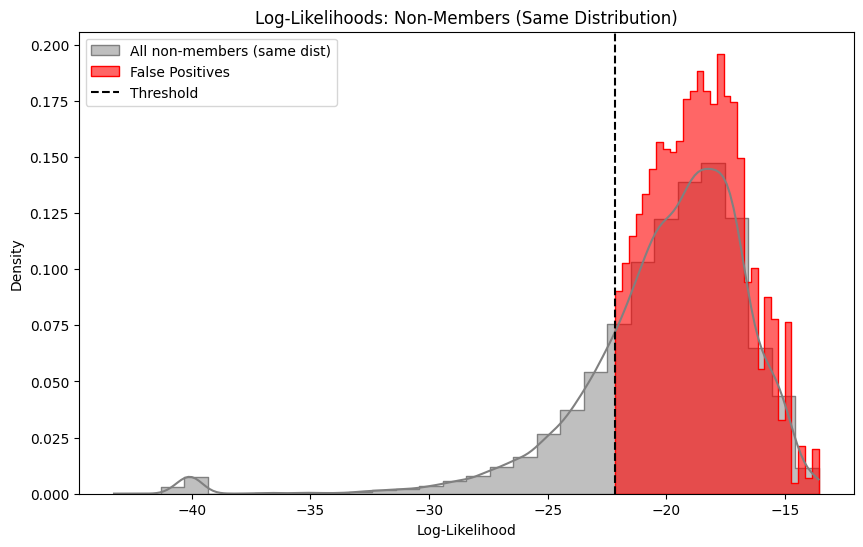

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Focus on test data from the same distribution
subset = results[results["source"] == "test_same_dist"]

# Split into false positives and true negatives
false_positives = subset[(subset["true_member"] == 0) & (subset["predicted_member"] == 1)]
true_negatives = subset[(subset["true_member"] == 0) & (subset["predicted_member"] == 0)]

plt.figure(figsize=(10, 6))

# Plot full distribution
sns.histplot(subset["log_likelihood"], bins=30, color='gray', label='All non-members (same dist)', kde=True, element="step", stat="density")

# Overlay false positives
sns.histplot(false_positives["log_likelihood"], bins=30, color='red', label='False Positives', kde=False, alpha=0.6, element="step", stat="density")

plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel("Log-Likelihood")
plt.ylabel("Density")
plt.title("Log-Likelihoods: Non-Members (Same Distribution)")
plt.legend()
plt.show()


In [12]:
"{:.7f}".format(float(np.exp(-15)))

'0.0000003'